# Purpose:
- Stats of GLM fit from Thyme
    - Distribution of variance explained
    - Total variance explained across sessions
    - Example trace of fitting
- This can be developed into 'glm_analysis_tools'

In [70]:
import sys
sys.path.append('/root/capsule/code/')

from DesignMatrix import DesignMatrix
import glm_fit_tools as gft
import design_matrix_tools as dmtools
import kernel_tools as ktools
import load_data
import vba_tools

from comb.behavior_ophys_dataset import BehaviorOphysDataset, BehaviorMultiplaneOphysDataset
from comb.behavior_session_dataset import BehaviorSessionDataset
from lamf_analysis import utils as lamf_utils
from skimage import measure
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import json
from tqdm import tqdm
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns


# notebook dev
%load_ext autoreload
%autoreload 2
%matplotlib inline
import capsule_utils
import load_data
import design_matrix_tools as dmtools
import kernel_tools as ktools

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# GLM parameters
dm_version = 2
data_type = 'events'
suffix = ''

# Loading session information

data_dir = '/root/capsule/data'
data_folders = [d for d in glob.glob(data_dir + '/*') if Path(d).is_dir()]
raw_paths = np.sort([d for d in data_folders if ('processed' not in d.split('/')[-1]) and
                 ('dlc-eye' not in d.split('/')[-1]) and
                 ('multiplane-ophys' in d.split('/')[-1]) and 
                 ('stimuli' not in d.split('/')[-1]) and
                 ('stim-response' not in d.split('/')[-1]) and
                 ('ROICat' not in d.split('/')[-1])])
glm_dir = '/root/capsule/scratch/Thyme'

session_names = [rp.split('/')[-1] for rp in raw_paths]
session_keys = ['_'.join(sn.split('_')[1:3]) for sn in session_names]
session_inds = np.arange(len(session_names))
session_types = []
for raw_path in raw_paths:
    session_json_fn = Path(raw_path) / 'session.json'
    with open(session_json_fn) as f:
        session_json = json.load(f)
    session_types.append(session_json['session_type'])
session_info_df = pd.DataFrame({'session_name': session_names,
                                'session_key': session_keys,
                                'session_ind': session_inds,
                                'session_type': session_types}) 
session_info_df.set_index('session_key', drop=True, inplace=True)


In [3]:
# Loading ROICat results
roicat_dir = Path('/root/capsule/data/multiplane-ophys_ROICat_736963_natural_images_250118')
roicat_folder_names = np.arange(8)
roicat_df_list = []
for folder_names in roicat_folder_names:
    roicat_fp = roicat_dir / f'{folder_names}/ROICaT.tracking.results.csv'
    roicat_df = pd.read_csv(roicat_fp)
    roicat_df['session_key'] = roicat_df['session_name'].apply(lambda x: '_'.join(x.split('_')[1:3]))
    roicat_df['roi_name'] = roicat_df.apply(lambda x: '_'.join(
        [x.session_key, x.fov_name, f'{x.roi_session_index:04}']), axis=1)
    roicat_df['session_ind'] = roicat_df.session_key.map(lambda x: session_info_df.loc[x, 'session_ind'])
    roicat_df['unique_cell_name'] = roicat_df.apply(lambda x: x.fov_name + f'_{x.ucid:04}', axis=1)
    roicat_df_list.append(roicat_df)
roicat_df = pd.concat(roicat_df_list)

In [4]:
session_ind = 0
session_name = session_info_df.query('session_ind==@session_ind').session_name.values[0]
session_key = session_info_df.query('session_ind==@session_ind').index.values[0]
glm_path = Path(glm_dir) / f'glm_results_v{dm_version:02}_{session_name}_{data_type}{suffix}.npy'
glm_results = np.load(glm_path, allow_pickle=True).item()

In [6]:
glm_results.keys()

dict_keys(['fit_params', 'use_indices', 'stratified_frames', 'cv_inds_stratified', 'lambdas_cv', 'W_cv', 'var_explained_train_cv', 'var_explained_test_cv', 'vr_test_train_ratio_cv', 'var_explained_mean_model'])

In [17]:
full_ve = glm_results['var_ratio_mean_model'].sel(model='Full').squeeze()
# remove 'model' dimension


In [7]:
full_ve_list = []
for session_ind in tqdm(range(11)):
    session_name = session_info_df.query('session_ind==@session_ind').session_name.values[0]
    session_key = session_info_df.query('session_ind==@session_ind').index.values[0]
    glm_path = Path(glm_dir) / f'glm_results_v{dm_version:02}_{session_name}_{data_type}{suffix}.npy'
    glm_results = np.load(glm_path, allow_pickle=True).item()
    
    full_ve = glm_results['var_explained_mean_model'].sel(model='Full').squeeze()
    
    matched_unique_cell_name = []
    session_roi_cat_df = roicat_df.query(f'session_ind=={session_ind}')
    matched_df = session_roi_cat_df.query('matched==True')
    matched_roi_id = ['_'.join(rn.split('_')[2:]) for rn in matched_df.roi_name.values]
    
    zero_activity_cell_roi_ids = list(set(matched_roi_id) - set(full_ve.cell_roi_id.values))
    # add zero values to full_ve
    zero_xr = xr.DataArray(np.zeros(len(zero_activity_cell_roi_ids)), 
                        coords=[zero_activity_cell_roi_ids], 
                        dims=['cell_roi_id'])
    full_ve = xr.concat([full_ve, zero_xr], dim='cell_roi_id')
    full_ve = full_ve.sel(cell_roi_id=matched_roi_id)
    
    unique_cell_names = []
    for cell_roi_id in full_ve.cell_roi_id.values:
        roi_name = f'{session_key}_{cell_roi_id}'
        unique_cell_names.append(session_roi_cat_df.query(f'roi_name=="{roi_name}"').unique_cell_name.values[0])
    full_ve = full_ve.assign_coords(unique_cell_name=("cell_roi_id", unique_cell_names))
    full_ve = full_ve.swap_dims({"cell_roi_id": "unique_cell_name"})
    full_ve = full_ve.assign_coords(session_key=session_key)
    
    full_ve_list.append(full_ve)
full_ve_sessions = xr.concat(full_ve_list, dim='session_key')

  0%|          | 0/11 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:22<00:00,  2.08s/it]


In [41]:
full_ve_sessions.session_key.values

array(['736963_2024-07-24', '736963_2024-07-26', '736963_2024-07-29',
       '736963_2024-07-30', '736963_2024-08-01', '736963_2024-08-05',
       '736963_2024-08-06', '736963_2024-08-07', '736963_2024-08-09',
       '736963_2024-08-12', '736963_2024-08-13'], dtype='<U17')

In [8]:
num_matched_sessions_threshold = 11
num_matching_series = roicat_df.query('matched').groupby('unique_cell_name').size()
all_matched_unique_cell_names = num_matching_series.index.values[np.where(num_matching_series>=num_matched_sessions_threshold)[0]]
all_matched_full_ve = full_ve_sessions.sel(unique_cell_name=all_matched_unique_cell_names)

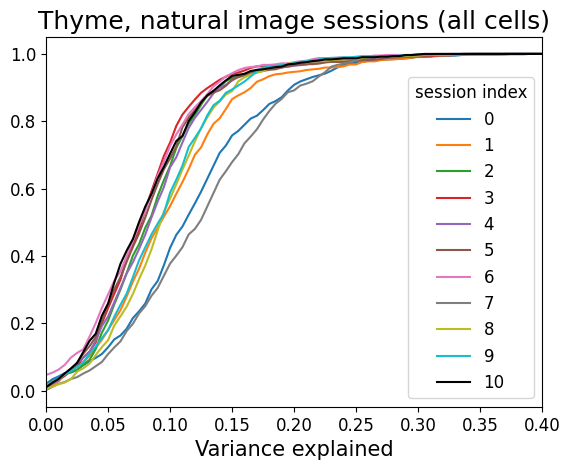

In [10]:
bins = np.linspace(0, 0.5, 101)
median_values = []
fig, ax = plt.subplots()
for i, session_key in enumerate(full_ve_sessions.session_key.values):
    full_ve_session = full_ve_sessions.sel(session_key=session_key).values
    dist_vals = np.histogram(full_ve_session, bins=bins)[0]
    cumdist = np.cumsum(dist_vals) / np.sum(dist_vals)
    
    median_values.append(bins[np.argmin(np.abs(cumdist-0.5))])
    
    if i == 10:
        color = 'k'
    else:
        color = f'C{i}'
    ax.plot(bins[:-1], cumdist, label=session_info_df.loc[session_key].session_ind, color=color)
ax.set_xlim((0, 0.4))
ax.legend(title='session index', fontsize=12, title_fontsize=12)
ax.set_xlabel('Variance explained', fontsize=15)
ax.set_title('Thyme, natural image sessions (all cells)', fontsize=18)
ax.tick_params(axis='both', labelsize=12)

In [13]:
np.std(median_values)

0.015089266066088939

In [12]:
np.mean(median_values)

0.08863636363636362

In [14]:
ve_sorted_inds = np.argsort(-all_matched_full_ve.isel(session_key=0), axis=0).squeeze()

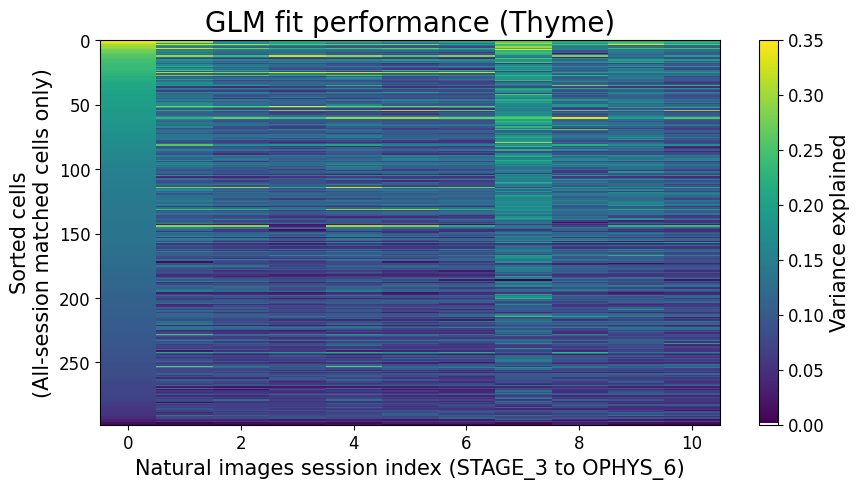

In [15]:
fig, ax = plt.subplots(figsize=(10,5))
values = all_matched_full_ve.values.T
sorted_values = values[ve_sorted_inds,:]
im = ax.imshow(sorted_values,
          aspect='auto',
          interpolation='none',
            vmax=0.35)
cbar = plt.colorbar(im)
cbar.set_ticks(np.linspace(0, 0.35, 8))
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Variance explained', fontsize=15)
ax.set_xlabel('Natural images session index (STAGE_3 to OPHYS_6)', fontsize=15)
ax.set_ylabel('Sorted cells\n(All-session matched cells only)', fontsize=15)
ax.set_title('GLM fit performance (Thyme)', fontsize=20)
ax.tick_params(axis='both', labelsize=12)

In [63]:
all_matched_full_ve

<xarray.DataArray (session_key: 11, unique_cell_name: 299)> Size: 26kB
array([[0.05630744, 0.16694461, 0.13568541, ..., 0.03945155, 0.12290581,
        0.15566391],
       [0.03521872, 0.08348794, 0.06330455, ..., 0.03633327, 0.09264399,
        0.10124844],
       [0.05545896, 0.0673959 , 0.04536198, ..., 0.04780936, 0.04488614,
        0.06180977],
       ...,
       [0.11754027, 0.04381925, 0.0704038 , ..., 0.06227879, 0.10025661,
        0.04786055],
       [0.09962905, 0.05105189, 0.0807974 , ..., 0.08110823, 0.05190365,
        0.06607272],
       [0.08223763, 0.04639549, 0.0544877 , ..., 0.05900617, 0.02773368,
        0.03523523]])
Coordinates:
  * unique_cell_name  (unique_cell_name) <U11 13kB 'VISp_0_0006' ... 'VISp_7_...
    model             <U4 16B 'Full'
    cell_roi_id       (session_key, unique_cell_name) object 26kB 'VISp_0_001...
  * session_key       (session_key) <U17 748B '736963_2024-07-24' ... '736963...

# One example fit result

In [16]:
session_ind = 7 # novel session
session_name = session_info_df.query('session_ind==@session_ind').session_name.values[0]
session_key = session_info_df.query('session_ind==@session_ind').index.values[0]
glm_path = Path(glm_dir) / f'glm_results_v{dm_version:02}_{session_name}_{data_type}{suffix}.npy'
glm_results = np.load(glm_path, allow_pickle=True).item()

In [42]:
X, response, response_info, run_params, unstd_features, use_indices = \
            gft.load_data(session_name, data_type, dm_version, load_path=glm_dir)

In [18]:
glm_results.keys()

dict_keys(['fit_params', 'use_indices', 'stratified_frames', 'cv_inds_stratified', 'lambdas_cv', 'W_cv', 'var_explained_train_cv', 'var_explained_test_cv', 'vr_test_train_ratio_cv', 'var_explained_mean_model'])

In [43]:
use_indices = glm_results['use_indices']
X_trim = X[use_indices, :]
response_trim = response[use_indices, :]

In [44]:
best_fit_cell_ind = glm_results['var_explained_mean_model'].sel(model='Full').argmax()
best_fit_roi_id = glm_results['var_explained_mean_model'].cell_roi_id.values[best_fit_cell_ind]
fit_performance = glm_results['var_explained_mean_model'].sel(cell_roi_id=best_fit_roi_id,
                                        model='Full').values
best_fit_cell_Full_W_mean = glm_results['W_cv'].sel(model='Full', cell_roi_id=best_fit_roi_id).mean('test_fold_ind')

response = response_trim.sel(cell_roi_id=best_fit_roi_id)
mean_W_model = X_trim @ best_fit_cell_Full_W_mean

Text(0.5, 1.0, 'multiplane-ophys_736963_2024-08-07_09-11-10 best fit cell (VISp_5_0080, 0.34)')

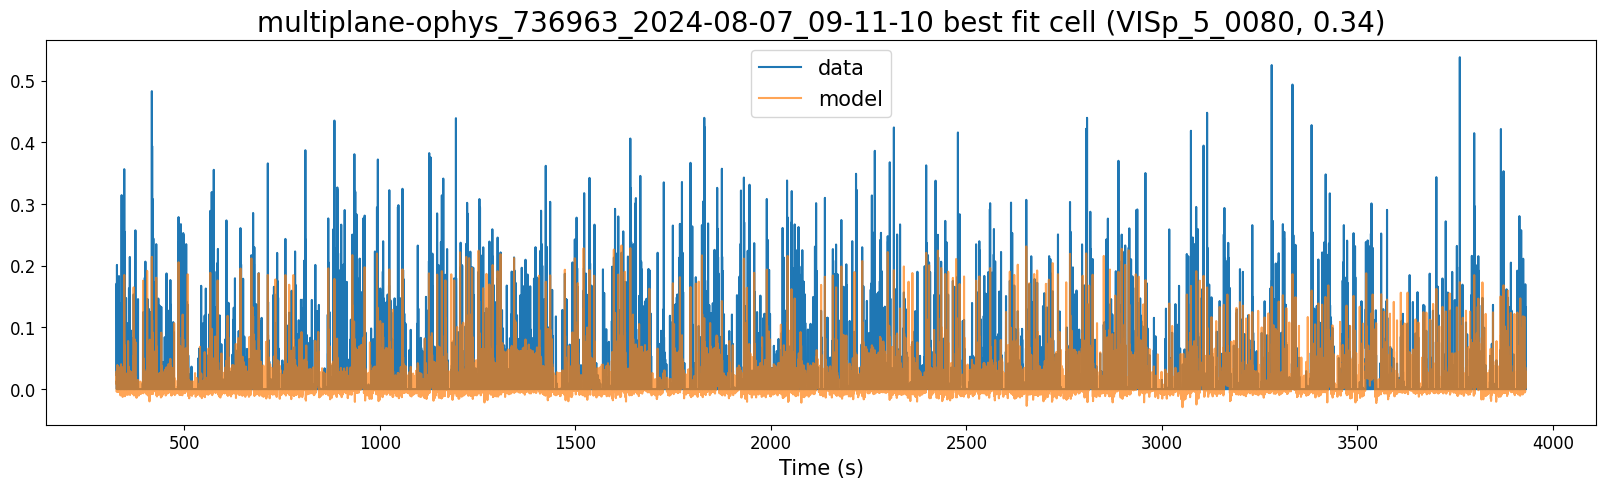

In [24]:
fig, ax = plt.subplots(figsize=(20,5))
ax.plot(response_trim.timestamps, response.values, label='data')
ax.plot(response_trim.timestamps, mean_W_model, label='model', alpha=0.7)
ax.legend(fontsize=15)
ax.set_xlabel('Time (s)', fontsize=15)
ax.tick_params(axis='both', labelsize=12)
ax.set_title(f'{session_name} best fit cell ({best_fit_roi_id}, {fit_performance:.2f})',
             fontsize=20)

(-0.1, 0.5)

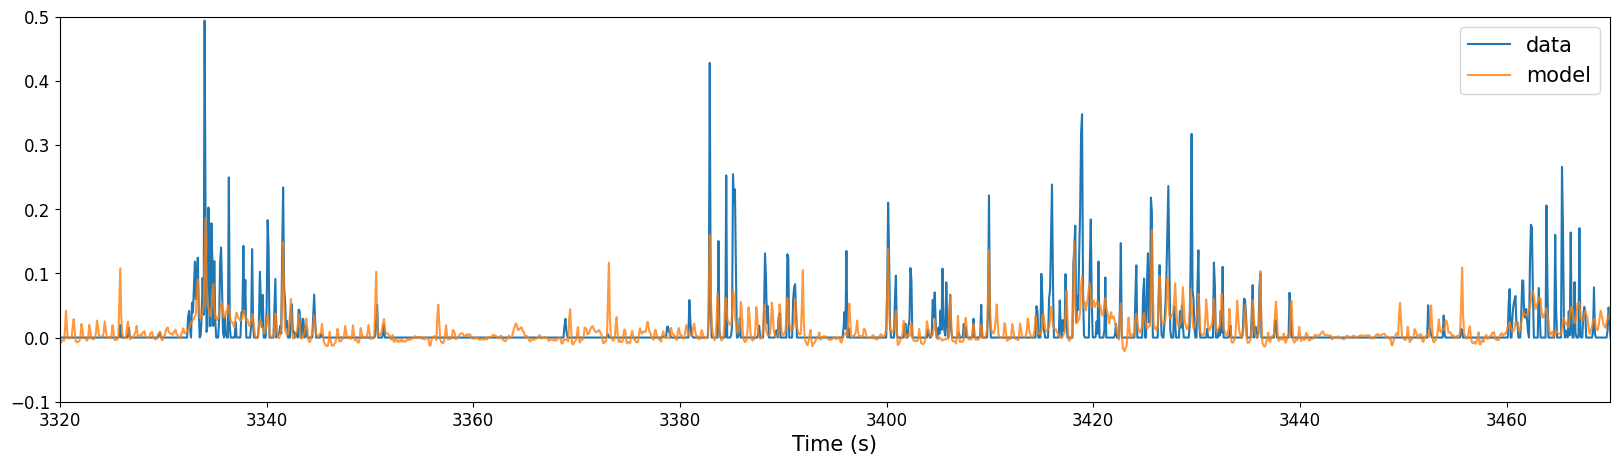

In [35]:
start_time = 3320
time_window = 150
fig, ax = plt.subplots(figsize=(20,5))
ax.plot(response_trim.timestamps, response.values, label='data')
ax.plot(response_trim.timestamps, mean_W_model, label='model', alpha=0.8)
ax.legend(fontsize=15)
ax.set_xlabel('Time (s)', fontsize=15)
ax.tick_params(axis='both', labelsize=12)
ax.set_xlim((start_time, start_time + time_window))
ax.set_ylim((-0.1, 0.5))

## getting the kernels

In [74]:
def get_weight_names(W, kernel):
    if kernel == 'all-images':
        kernel_names = [w for w in W.weights.values if w.startswith('im') and len(w.split('_')[0])==5]
        im_names = np.unique([k[2:5] for k in kernel_names])
        weight_inds = np.sort(np.unique([int(w.split('_')[-1]) for w in kernel_names]))
        weights = []
        for im_name in im_names:
            weights.append([f'im{im_name}_{wi}' for wi in weight_inds])
    else:
        weights = np.array([w for w in W.weights.values if w.startswith(kernel)])
        weight_inds = np.array([int(w.split('_')[-1]) for w in weights])
        weights = weights[np.argsort(weight_inds)]
    return weights

In [65]:
kernels = list(run_params['kernels'].keys())
kernels.append('all-images')
kernels

['intercept',
 'hits',
 'misses',
 'omissions',
 'running',
 'pupil',
 'licks',
 'im000',
 'im031',
 'im035',
 'im045',
 'im054',
 'im073',
 'im075',
 'im106',
 'all-images']

/tmp/ipykernel_15429/1756311005.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


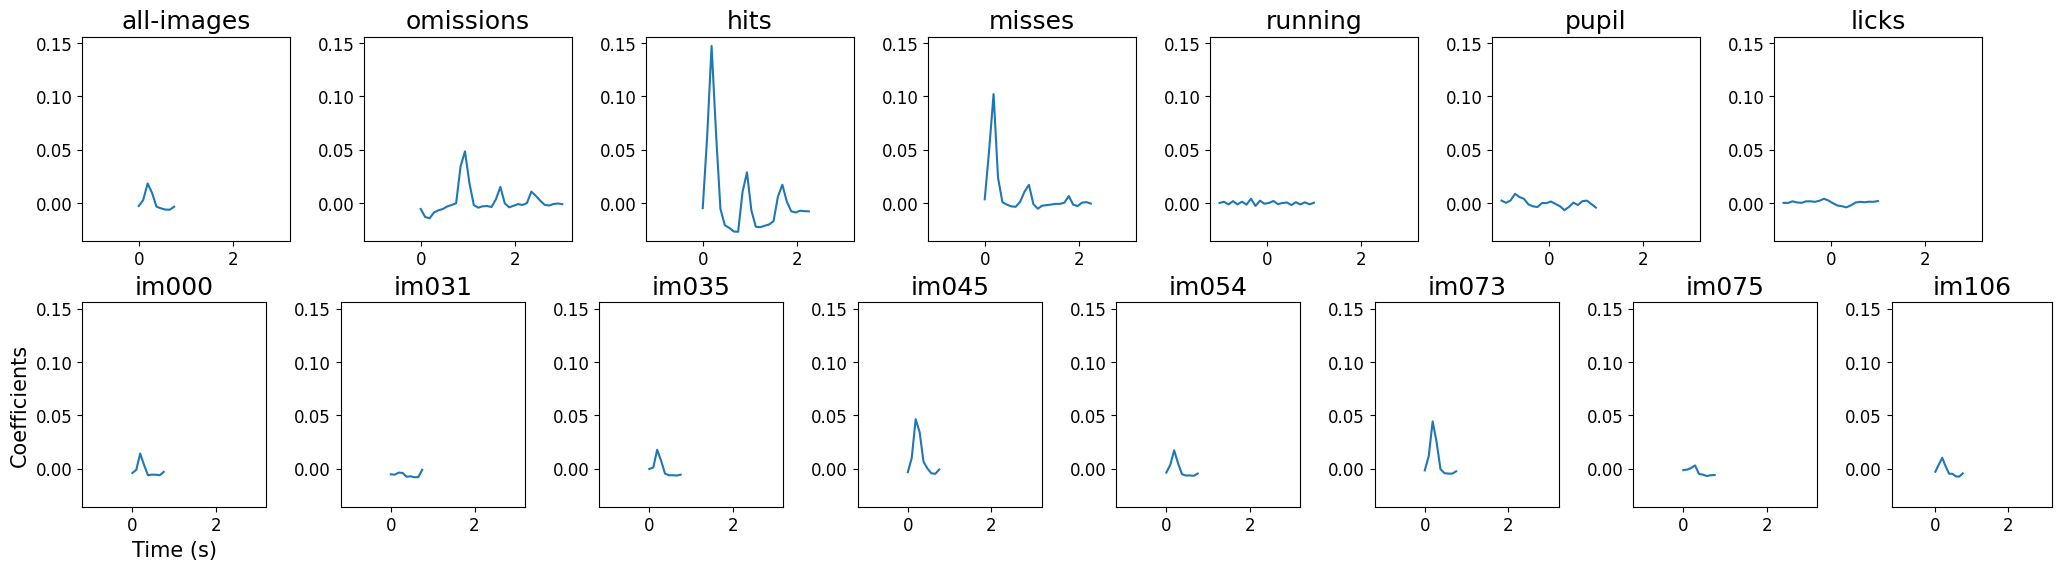

In [104]:
kernels = ['all-images', 'omissions', 'hits', 'misses', 'running', 'pupil', 'licks',
 'im000', 'im031', 'im035', 'im045', 'im054', 'im073', 'im075', 'im106']
fig, ax = plt.subplots(figsize=(20,5), sharex=True, sharey=True)
ax.axis('off')
gs = gridspec.GridSpec(2, 84)
column_width = 9
gs.update(hspace=0.3)
# First row: Only 3 subplots, spanning across the first 3 columns
all_axes = []
for i in range(7):
    start = i * 12
    end = start + column_width
    if i == 0:
        ax = fig.add_subplot(gs[0, start: end])  # First subplot (base)
    else:
        ax = fig.add_subplot(gs[0, start: end], sharex=all_axes[0], sharey=all_axes[0])
    all_axes.append(ax)
for i in range(8):
    start = i * 11
    end = start + 8
    all_axes.append(fig.add_subplot(gs[1, start: end], sharex=all_axes[0], sharey=all_axes[0]))
# Optional: Label subplots for clarity
for ki, ax in enumerate(all_axes):
    kernel = kernels[ki]
    weight_names = np.array(get_weight_names(best_fit_cell_Full_W_mean, kernel))
    if len(weight_names.shape) == 2:
        for wi in range(weight_names.shape[0]):
            temp_weights = best_fit_cell_Full_W_mean.sel(weights=weight_names[wi, :])
            im_name = weight_names[wi, 0].split('_')[0]
            temp_weights = temp_weights.expand_dims('im_name').assign_coords(im_name=[im_name])
            kernel_inds = np.array([int(w.split('_')[-1]) for w in temp_weights.weights.values])
            temp_weights = temp_weights.assign_coords(kernel_inds=('weights', kernel_inds))
            temp_weights = temp_weights.swap_dims({"weights": "kernel_inds"}).reset_coords('weights', drop=True)
            if wi == 0:
                weights = temp_weights.copy()
            else:
                weights = xr.concat([weights, temp_weights], dim='im_name')
        weights = weights.mean(dim='im_name')
        
        mock_kernel = [k for k in run_params['kernels'].keys() if k.startswith('im')][0]
        offset = run_params['kernels'][mock_kernel]['offset']
        length = run_params['kernels'][mock_kernel]['length']
    elif len(weight_names.shape) == 1:
        weights = best_fit_cell_Full_W_mean.sel(weights=weight_names)
        offset = run_params['kernels'][kernel]['offset']
        length = run_params['kernels'][kernel]['length']
    else:
        raise ValueError('weight_names shape is wrong')
    x = np.linspace(offset, offset + length, len(weights))
    ax.plot(x, weights)
    ax.tick_params(axis='both', labelsize=12)
    ax.set_title(kernel, fontsize=18)
    
    if ki == 7:
        ax.set_xlabel('Time (s)', fontsize=15)
        ax.set_ylabel('Coefficients', fontsize=15)
fig.tight_layout()

## Mean responses

In [115]:
mean_response_dir = Path('/root/capsule/scratch/Thyme/responses_condition_v1')
response_fn = mean_response_dir / f'response_v1_{session_name}.feather'
session_response_df = pd.read_feather(response_fn).reset_index(drop=False).rename(columns={'cell_roi_id': 'session_roi_index'})
    
conditions = session_response_df.condition.unique()
image_condition = [condition for condition in conditions if 'image' in condition][0]
session_response_df.loc[session_response_df.condition==image_condition, 'condition'] = 'all-images'

# session_response_df['session_roi_id'] = session_response_df.apply(lambda x: f'{x.session_key}_{x.plane_name}_{x.session_roi_index:04}',
#                                                                     axis=1)
session_response_df['roi_id'] = session_response_df.apply(lambda x: f'{x.plane_name}_{x.session_roi_index:04}',
                                                                    axis=1)


In [119]:
roi_response_df = session_response_df.query(f'roi_id=="{best_fit_roi_id}"')
roi_timestamps = roi_response_df.timestamps.values
assert np.all([np.array_equal(ts, roi_timestamps[0]) for ts in roi_timestamps])
timestamps = roi_timestamps[0]

In [120]:
roi_response_df.condition.unique()

array(['all-images', 'is_change', 'omitted'], dtype=object)

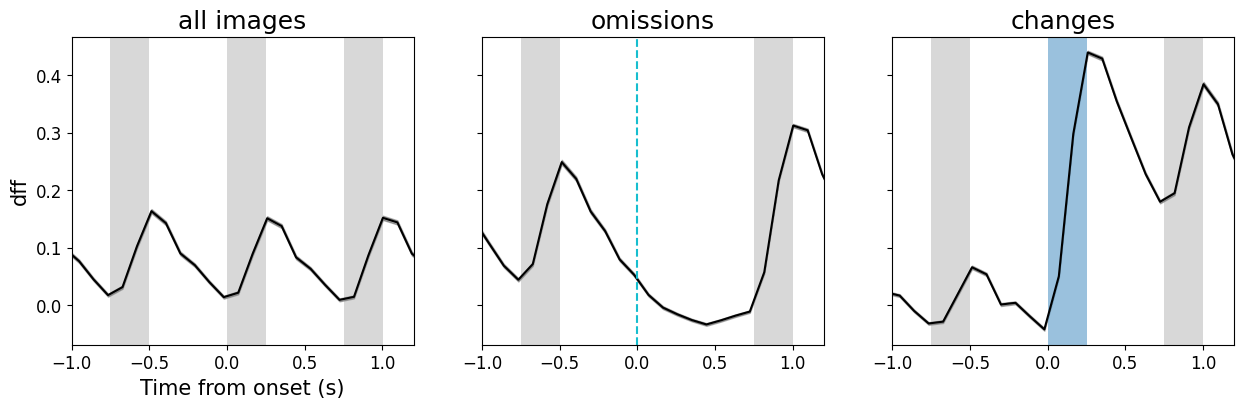

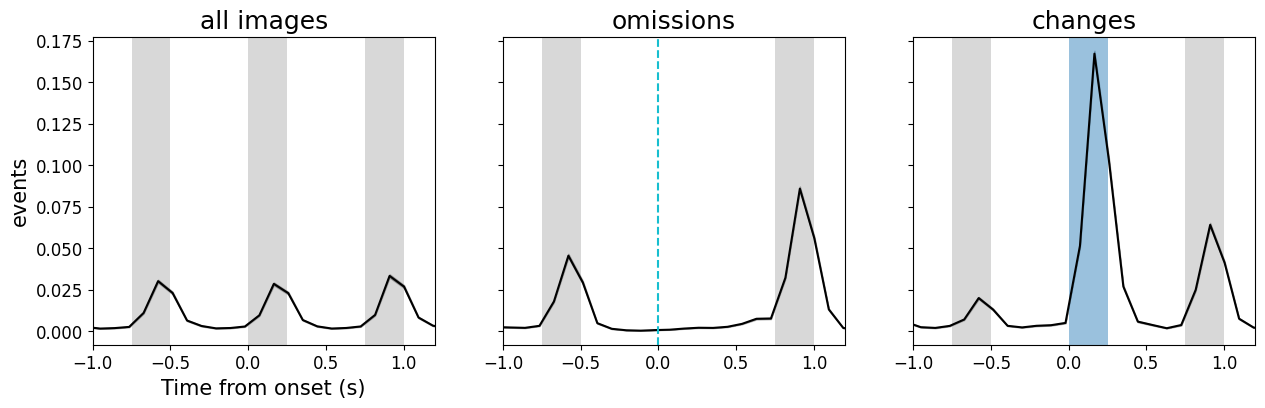

In [137]:
for data_type in ['dff', 'events']:
    conditions = ['all-images', 'omitted', 'is_change']
    titles = ['all images', 'omissions', 'changes']
    time_window = [-1, 1.2]
    fig, ax = plt.subplots(1, 3, figsize=(15,4), sharex=True, sharey=True)
    for ci, condition in enumerate(conditions):
        row =  roi_response_df.query(
            f'data_type=="{data_type}" and condition=="{condition}"').iloc[0]
        ax[ci].fill_between(timestamps, row.mean_trace + row.sem_trace, row.mean_trace - row.sem_trace,
                            color='k', alpha=0.3)
        ax[ci].plot(timestamps, row.mean_trace, color='k')
        ax[ci].set_title(titles[ci], fontsize=18)
        ax[ci].set_xlim(time_window)
        ax[ci].tick_params(axis='both', labelsize=12)
        if 'change' in condition:
            vba_tools.plot_flashes_on_trace(ax[ci], timestamps, change_time=0, change=True,
                                            alpha=0.3)
        elif 'omitted' in condition:
            vba_tools.plot_flashes_on_trace(ax[ci], timestamps, change_time=0, omitted=True,
                                            alpha=0.3)
        else:
            vba_tools.plot_flashes_on_trace(ax[ci], timestamps, change_time=0,
                                            alpha=0.3)
        if ci == 0:
            ax[ci].set_xlabel('Time from onset (s)', fontsize=15)
            ax[ci].set_ylabel(data_type, fontsize=15)

# DataFrame for coding score clustering
- VE for 'Full', 'all-images', 'omissions', 'task', 'behavioral'
- For all the sessions with omissions?
    - with session_info_df
    - ROI matching results is necessary, so 2 different sets.
        - One with F, N, N+1
        - Another with F0, F1, N0, N1, N2E0, N3E1
- tidy DF form

In [56]:
session_info_df

,session_name,session_ind,session_type
session_key,,,
736963_2024-07-24,multiplane-ophys_736963_2024-07-24_08-49-57,0,TRAINING_3_images_A_10uL_reward
736963_2024-07-26,multiplane-ophys_736963_2024-07-26_09-37-45,1,TRAINING_3_images_A_10uL_reward
736963_2024-07-29,multiplane-ophys_736963_2024-07-29_09-00-58,2,TRAINING_4_images_A_training
736963_2024-07-30,multiplane-ophys_736963_2024-07-30_09-11-03,3,TRAINING_5_images_A_epilogue
736963_2024-08-01,multiplane-ophys_736963_2024-08-01_08-59-00,4,TRAINING_5_images_A_handoff_ready
736963_2024-08-05,multiplane-ophys_736963_2024-08-05_09-19-25,5,OPHYS_1_images_A
736963_2024-08-06,multiplane-ophys_736963_2024-08-06_08-52-03,6,OPHYS_1_images_A
736963_2024-08-07,multiplane-ophys_736963_2024-08-07_09-11-10,7,OPHYS_4_images_B
736963_2024-08-09,multiplane-ophys_736963_2024-08-09_08-58-36,8,OPHYS_4_images_B


In [52]:
glm_results['var_ratio_mean_model'].model.values

array(['Full', 'intercept', 'hits', 'misses', 'omissions', 'running',
       'licks', 'im000', 'im031', 'im035', 'im045', 'im054', 'im073',
       'im075', 'im106', 'all-images', 'task', 'behavioral',
       'single-hits', 'single-misses', 'single-omissions',
       'single-running', 'single-licks', 'single-im000', 'single-im031',
       'single-im035', 'single-im045', 'single-im054', 'single-im073',
       'single-im075', 'single-im106', 'single-all-images', 'single-task',
       'single-behavioral'], dtype=object)

In [57]:
roicat_df

,roi_index,fov_name,session_name,roi_session_index,ucid,roi_id,silhouette,hdbscan_probability,matched,session_key,roi_name,session_ind,unique_cell_name
0,0,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,0,0,262a6faa-c5b5-42ad-b3b1-6a81b1d2b56f,0.837110,1.000000,True,736963_2024-08-09,736963_2024-08-09_VISp_0_0000,8,VISp_0_0000
1,1,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,1,5,c163d427-d684-426d-9b1b-57b3e2c9f9b0,0.858987,0.969619,True,736963_2024-08-09,736963_2024-08-09_VISp_0_0001,8,VISp_0_0005
2,2,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,2,11,d6b7d50a-9fcf-4eb0-89f4-4fe387a32df2,0.950333,1.000000,True,736963_2024-08-09,736963_2024-08-09_VISp_0_0002,8,VISp_0_0011
3,3,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,3,12,d81f0deb-c985-49d6-8cc2-6254ac72b930,0.927172,1.000000,True,736963_2024-08-09,736963_2024-08-09_VISp_0_0003,8,VISp_0_0012
4,4,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,4,13,4178072d-8dfb-4923-bea3-9b1f2fbafae9,0.883920,0.994637,True,736963_2024-08-09,736963_2024-08-09_VISp_0_0004,8,VISp_0_0013
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1108,1108,VISp_7,multiplane-ophys_736963_2024-08-06_08-52-03_pr...,101,59,2c99c34f-5b69-4339-b169-78cace450a67,0.993811,1.000000,True,736963_2024-08-06,736963_2024-08-06_VISp_7_0101,6,VISp_7_0059
1109,1109,VISp_7,multiplane-ophys_736963_2024-08-06_08-52-03_pr...,102,61,62aef4cb-0534-4997-afa7-ab211218c2f8,0.985281,0.789902,True,736963_2024-08-06,736963_2024-08-06_VISp_7_0102,6,VISp_7_0061
1110,1110,VISp_7,multiplane-ophys_736963_2024-08-06_08-52-03_pr...,103,129,1607d60f-8229-434e-bfd8-17b27e50f52d,0.984575,0.564651,True,736963_2024-08-06,736963_2024-08-06_VISp_7_0103,6,VISp_7_0129
1111,1111,VISp_7,multiplane-ophys_736963_2024-08-06_08-52-03_pr...,104,63,0e0003f6-9549-46b8-8d8e-db53d36b8d34,0.987950,0.635238,True,736963_2024-08-06,736963_2024-08-06_VISp_7_0104,6,VISp_7_0063


In [60]:
roicat_df.groupby('session_ind').size().mean()

642.6363636363636

In [140]:
def get_roi_df_with_valid_roi(bod, small_roi_radius_threshold_in_um=4):
    # This mutates bod.cell_specimen_table, so need to be run only once per bod loading
    cell_specimen_table = bod.cell_specimen_table
    if np.array([k in cell_specimen_table.columns for k in ['touching_motion_border', 'small_roi', 'valid_roi']]).all():
        return cell_specimen_table
    else:
        plane_path = bod.metadata['plane']['plane_path']
        range_y, range_x = lamf_utils.get_motion_correction_crop_xy_range(plane_path)
        range_y = [int(range_y[0]), -int(range_y[1])]
        range_x = [int(range_x[0]), -int(range_x[1])]
        
        on_mask = np.zeros((bod.metadata['plane']['fov_height'], bod.metadata['plane']['fov_width']), dtype=bool)
        on_mask[range_y[0]:range_y[1], range_x[0]:range_x[1]] = True
        motion_mask = ~on_mask

        def _touching_motion_border(row, motion_mask):
            if (row.mask_matrix * motion_mask).any():
                return True
            else:
                return False

        cell_specimen_table['touching_motion_border'] = cell_specimen_table.apply(_touching_motion_border, axis=1, motion_mask=motion_mask)
        
        small_roi_radius_threshold_in_pix = small_roi_radius_threshold_in_um / float(bod.metadata['plane']['fov_scale_factor'])
        area_threshold = np.pi * (small_roi_radius_threshold_in_pix**2)
        
        cell_specimen_table['small_roi'] = cell_specimen_table['mask_matrix'].apply(lambda x: len(np.where(x)[0]) < area_threshold)
        cell_specimen_table['valid_roi'] = ~cell_specimen_table['touching_motion_border'] & ~cell_specimen_table['small_roi']
    
    return cell_specimen_table


def plot_contour_and_projections_all(roi_df, img, mask_key="mask_matrix",
                                 vmin=None, vmax=None, colors=['y','r'], ax=None,
                                 ind=None):
    
    # plot contours
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))
    if vmax is None:
        vmax = np.percentile(img, 99.6)
    if vmin is None:
        vmin = np.percentile(img, 0.4)
    ax.imshow(img, vmin=vmin, vmax=vmax, cmap=plt.cm.gray)

    if ind is not None:
        row = roi_df.iloc[ind]
        x = row['x']
        y = row['y']
        mask = np.array(row[mask_key]>0)
        pad = 5
        mask = np.pad(mask, pad, mode='constant', constant_values=0) # pad mask so contour works on edge
        contours = measure.find_contours(mask, 0.5)
        color = colors[int(row['valid_roi'])]
        
        for n, contour in enumerate(contours):
            contour = contour - pad # remove pad from contour
            ax.plot(contour[:, 1], contour[:, 0], linewidth=.5, color=color)
    else:
        for roi_id, row in roi_df.iterrows():
            x = row['x']
            y = row['y']
            mask = np.array(row[mask_key]>0)
            pad = 5
            mask = np.pad(mask, pad, mode='constant', constant_values=0) # pad mask so contour works on edge
            contours = measure.find_contours(mask, 0.5)
            color = colors[int(row['valid_roi'])]
            
            for n, contour in enumerate(contours):
                contour = contour - pad # remove pad from contour
                ax.plot(contour[:, 1], contour[:, 0], linewidth=.5, color=color)

    ax.axis('off')


    return ax

(-0.5, 511.5, 511.5, -0.5)

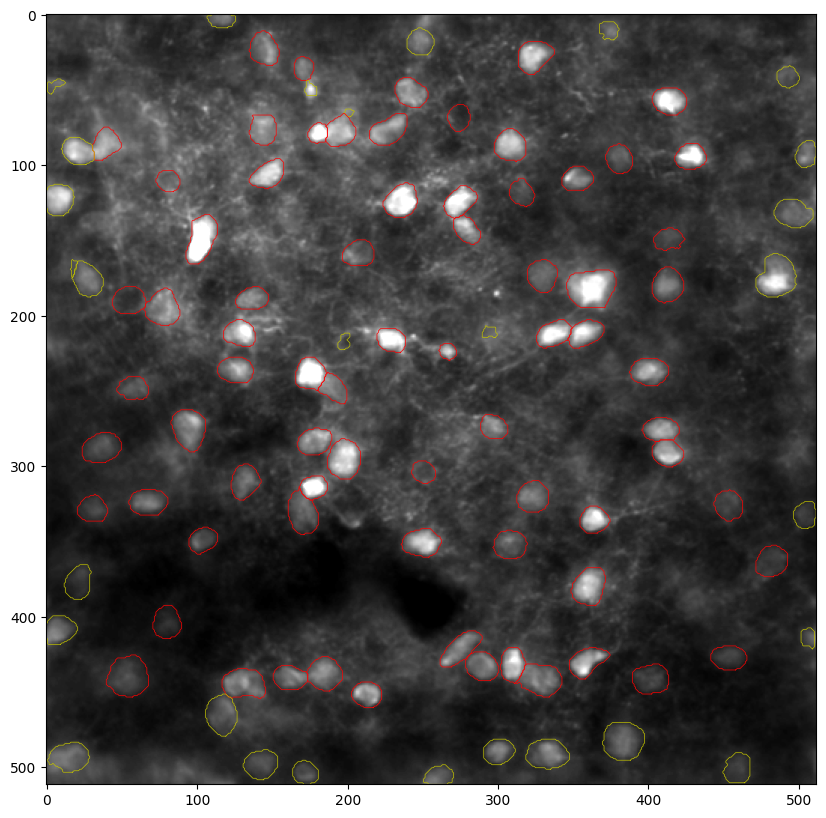

In [139]:
bod = BehaviorOphysDataset(raw_folder_path='/root/capsule/data/multiplane-ophys_736963_2024-07-24_08-49-57',
                           plane_folder_path='/root/capsule/data/multiplane-ophys_736963_2024-07-24_08-49-57_processed_2024-11-20_20-41-20/VISp_7',
                           pipeline_version='v6')

fig, ax = plt.subplots(figsize=(10, 10))
cell_specimen_table = get_roi_df_with_valid_roi(bod, small_roi_radius_threshold_in_um=4)
plot_contour_and_projections_all(cell_specimen_table, bod.ophys_plane_dataset.average_projection, ax=ax)
ax.axis('on')

### Create valid_roi table

In [141]:
session_info_df

,session_name,session_ind,session_type
session_key,,,
736963_2024-07-24,multiplane-ophys_736963_2024-07-24_08-49-57,0,TRAINING_3_images_A_10uL_reward
736963_2024-07-26,multiplane-ophys_736963_2024-07-26_09-37-45,1,TRAINING_3_images_A_10uL_reward
736963_2024-07-29,multiplane-ophys_736963_2024-07-29_09-00-58,2,TRAINING_4_images_A_training
736963_2024-07-30,multiplane-ophys_736963_2024-07-30_09-11-03,3,TRAINING_5_images_A_epilogue
736963_2024-08-01,multiplane-ophys_736963_2024-08-01_08-59-00,4,TRAINING_5_images_A_handoff_ready
736963_2024-08-05,multiplane-ophys_736963_2024-08-05_09-19-25,5,OPHYS_1_images_A
736963_2024-08-06,multiplane-ophys_736963_2024-08-06_08-52-03,6,OPHYS_1_images_A
736963_2024-08-07,multiplane-ophys_736963_2024-08-07_09-11-10,7,OPHYS_4_images_B
736963_2024-08-09,multiplane-ophys_736963_2024-08-09_08-58-36,8,OPHYS_4_images_B


In [142]:
cell_specimen_table

,cell_roi_id,mask_matrix,height,width,x,y,centroid,bounding_box,valid_roi,exclusion_labels,touching_motion_border,small_roi
0,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",8,18,107,0,"(116.0, 4.0)","[(0, 107, 8, 125)]",False,None,True,False
1,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",11,12,368,5,"(374.0, 10.5)","[(5, 368, 16, 380)]",False,None,True,False
2,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",17,17,240,9,"(248.5, 17.5)","[(9, 240, 26, 257)]",False,None,True,False
3,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",22,19,135,11,"(144.5, 22.0)","[(11, 135, 33, 154)]",True,None,False,False
4,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",21,23,314,18,"(325.5, 28.5)","[(18, 314, 39, 337)]",True,None,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
98,98,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",19,27,1,484,"(14.5, 493.5)","[(484, 1, 503, 28)]",False,None,True,False
99,99,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",19,22,131,489,"(142.0, 498.5)","[(489, 131, 508, 153)]",False,None,True,False
100,100,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",19,17,450,491,"(458.5, 500.5)","[(491, 450, 510, 467)]",False,None,True,False
101,101,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",15,16,164,496,"(172.0, 503.5)","[(496, 164, 511, 180)]",False,None,True,False


In [148]:
# Took 8 minutes
roi_df = pd.DataFrame()
for session_key, row in tqdm(session_info_df.iterrows()):
    session_name = row.session_name
    raw_path = f'/root/capsule/data/{session_name}'
    processed_path = glob.glob(f'/root/capsule/data/{session_name}_processed_*')[0]
    plane_dirs = [d for d in glob.glob(processed_path + '/*') if Path(d).is_dir() and \
                  ('nwb' not in d.split('/')[-1]) and (d[-1].isnumeric())]
    for plane_dir in tqdm(plane_dirs):
        bod = BehaviorOphysDataset(raw_folder_path=raw_path,
                                plane_folder_path=plane_dir,
                                pipeline_version='v6')
        cell_specimen_table = get_roi_df_with_valid_roi(bod, 
                                small_roi_radius_threshold_in_um=4)[
                                    ['cell_roi_id', 'valid_roi', 'exclusion_labels',
                                    'touching_motion_border', 'small_roi']].copy()
        cell_specimen_table['session_key'] = session_key
        cell_specimen_table['plane_session_key'] = bod.metadata['plane']['plane_session_key']
        cell_specimen_table['roi_name'] = cell_specimen_table.apply(lambda x: f'{x.plane_session_key}_{x.cell_roi_id:04}', axis=1)
        roi_df = pd.concat([roi_df, cell_specimen_table])


0it [00:00, ?it/s]WARNING:comb.file_handling:this function: (get_sync_file_path) has been moved to aind-ophys-data-access, will be removed in future


100%|██████████| 8/8 [00:31<00:00,  3.93s/it]
1it [00:31, 31.48s/it]WARNING:comb.file_handling:this function: (get_sync_file_path) has been moved to aind-ophys-data-access, will be removed in future
100%|██████████| 8/8 [00:33<00:00,  4.14s/it]
2it [01:04, 32.47s/it]WARNING:comb.file_handling:this function: (get_sync_file_path) has been moved to aind-ophys-data-access, will be removed in future
100%|██████████| 8/8 [00:40<00:00,  5.00s/it]
3it [01:44, 35.93s/it]WARNING:comb.file_handling:this function: (get_sync_file_path) has been moved to aind-ophys-data-access, will be removed in future
100%|██████████| 8/8 [00:50<00:00,  6.28s/it]
4it [02:34, 41.60s/it]WARNING:comb.file_handling:this function: (get_sync_file_path) has been moved to aind-ophys-data-access, will be removed in future
100%|██████████| 8/8 [00:43<00:00,  5.41s/it]
5it [03:18, 42.21s/it]WARNING:comb.file_handling:this function: (get_sync_file_path) has been moved to aind-ophys-data-access, will be removed in future
100%|

In [156]:
roi_df.set_index('roi_name', drop=True, inplace=True)
roicat_df.set_index('roi_name', drop=True, inplace=True)
unique_roi_df_columns = list(set(roi_df.columns) - set(roicat_df.columns))
roicat_df = roicat_df.join(roi_df[unique_roi_df_columns], how='left', rsuffix='_roi_df')

In [160]:
assert len(np.where(roicat_df.small_roi.isnull())[0]) == 0
assert len(np.where(roicat_df.valid_roi.isnull())[0]) == 0
assert len(np.where(roicat_df.touching_motion_border.isnull())[0]) == 0


In [159]:
roicat_df.to_pickle('/root/capsule/scratch/Thyme/roicat_df.pkl')

In [162]:
session_info_df

,session_name,session_ind,session_type
session_key,,,
736963_2024-07-24,multiplane-ophys_736963_2024-07-24_08-49-57,0,TRAINING_3_images_A_10uL_reward
736963_2024-07-26,multiplane-ophys_736963_2024-07-26_09-37-45,1,TRAINING_3_images_A_10uL_reward
736963_2024-07-29,multiplane-ophys_736963_2024-07-29_09-00-58,2,TRAINING_4_images_A_training
736963_2024-07-30,multiplane-ophys_736963_2024-07-30_09-11-03,3,TRAINING_5_images_A_epilogue
736963_2024-08-01,multiplane-ophys_736963_2024-08-01_08-59-00,4,TRAINING_5_images_A_handoff_ready
736963_2024-08-05,multiplane-ophys_736963_2024-08-05_09-19-25,5,OPHYS_1_images_A
736963_2024-08-06,multiplane-ophys_736963_2024-08-06_08-52-03,6,OPHYS_1_images_A
736963_2024-08-07,multiplane-ophys_736963_2024-08-07_09-11-10,7,OPHYS_4_images_B
736963_2024-08-09,multiplane-ophys_736963_2024-08-09_08-58-36,8,OPHYS_4_images_B


## Choose sessions and matched ROIs per choice of sessions
- F1-F2-N1-N2 (index 5,6,7,8)
    - Total 267 neurons
- F2-N1-N2 (index 6,7,8)
    - Total 292 neurons
- Add GLM results

In [222]:
f2n2_session_inds = [5, 6, 7, 8]
f2n2_roi_df = roicat_df.query('valid_roi and (session_ind in @f2n2_session_inds)')
f2n2_uc_series = f2n2_roi_df.groupby('unique_cell_name').size()
f2n2_matched_uc = f2n2_uc_series.index.values[np.where(f2n2_uc_series==len(f2n2_session_inds))[0]]
print(len(f2n2_matched_uc))
f2n2_all_matched_roi_df = f2n2_roi_df.query('unique_cell_name in @f2n2_matched_uc')

267


In [223]:
f1n2_session_inds = [6, 7, 8]
f1n2_roi_df = roicat_df.query('valid_roi and (session_ind in @f1n2_session_inds)')
f1n2_uc_series = f1n2_roi_df.groupby('unique_cell_name').size()
f1n2_matched_uc = f1n2_uc_series.index.values[np.where(f1n2_uc_series==len(f1n2_session_inds))[0]]
print(len(f1n2_matched_uc))
f1n2_all_matched_roi_df = f1n2_roi_df.query('unique_cell_name in @f1n2_matched_uc')

292


### GLM results df
- From ophys sessions only?

In [288]:
f2n2_dos_list = [] # dropout score (dos) for f2n2 sessions
model_names = ['Full', 'all-images', 'omissions', 'task', 'behavioral']
for session_ind in f2n2_session_inds:
    session_name = session_info_df.query('session_ind==@session_ind').session_name.values[0]
    session_key = session_info_df.query('session_ind==@session_ind').index.values[0]
    glm_path = Path(glm_dir) / f'glm_results_v00_{session_name}_events.npy'
    glm_results = np.load(glm_path, allow_pickle=True).item()
    
    ve = glm_results['var_ratio_mean_model'].sel(model=model_names).squeeze()
    
    session_roi_cat_df = f2n2_all_matched_roi_df.query(f'session_ind=={session_ind}')
    session_matched_roi_id = ['_'.join(rn.split('_')[2:]) for rn in session_roi_cat_df.index.values]
    
    zero_activity_cell_roi_ids = list(set(session_matched_roi_id) - set(ve.cell_roi_id.values))
    if len(zero_activity_cell_roi_ids) > 0:
        print(f'Zero activity cells: {len(zero_activity_cell_roi_ids)} from {session_key}\nAdding them with 0 VEs')
        # add zero values to ve
        zero_xr = xr.DataArray(np.zeros(len(zero_activity_cell_roi_ids)), 
                            coords=[zero_activity_cell_roi_ids], 
                            dims=['cell_roi_id'])
        ve = xr.concat([ve, zero_xr], dim='cell_roi_id')
    ve = ve.sel(cell_roi_id=session_matched_roi_id)
    
    # convert variance explained to dropout scores
    dropout_score = ve.sel(model='Full') - ve
    dropout_score.loc[dict(model='Full')] = ve.sel(model='Full')
    
    unique_cell_names = []
    for cell_roi_id in ve.cell_roi_id.values:
        roi_name = f'{session_key}_{cell_roi_id}'
        unique_cell_names.append(session_roi_cat_df.loc[roi_name].unique_cell_name)
    dropout_score = dropout_score.assign_coords(unique_cell_name=("cell_roi_id", unique_cell_names))
    dropout_score = dropout_score.swap_dims({"cell_roi_id": "unique_cell_name"})
    dropout_score = dropout_score.reset_coords('cell_roi_id', drop=True)
    dropout_score = dropout_score.assign_coords(session_key=session_key)
    f2n2_dos_list.append(dropout_score)
f2n2_dos_sessions = xr.concat(f2n2_dos_list, dim='session_key')
assert len(np.where(np.isnan(f2n2_dos_sessions))[0] ) == 0

Zero activity cells: 2 from 736963_2024-08-06
Adding them with 0 VEs


In [289]:
# convert xarray to pandas in tidy format
f2n2_cs_df = f2n2_dos_sessions.to_dataframe('dropout_score').reset_index()
f2n2_cs_df['session_ind'] = f2n2_cs_df.session_key.map(lambda x: session_info_df.loc[x, 'session_ind'])
f2n2_cs_df['session_type'] = f2n2_cs_df.session_key.map(lambda x: session_info_df.loc[x, 'session_type'])


In [290]:
f2n2_max_ve = f2n2_dos_sessions.sel(model='Full').max('session_key').reset_coords('model', drop=True)
f2n2_max_ve_df = f2n2_max_ve.to_dataframe('max_ve')
f2n2_max_ve_df

,max_ve
unique_cell_name,
VISp_0_0003,0.116016
VISp_0_0007,0.131815
VISp_0_0009,0.163720
VISp_0_0010,0.147386
VISp_0_0024,0.246492
...,...
VISp_7_0116,0.104751
VISp_7_0117,0.078587
VISp_7_0121,0.121742


In [291]:
f2n2_cs_df

,session_key,unique_cell_name,model,dropout_score,session_ind,session_type
0,736963_2024-08-05,VISp_0_0003,Full,0.043594,5,OPHYS_1_images_A
1,736963_2024-08-05,VISp_0_0003,all-images,0.016360,5,OPHYS_1_images_A
2,736963_2024-08-05,VISp_0_0003,omissions,0.002525,5,OPHYS_1_images_A
3,736963_2024-08-05,VISp_0_0003,task,0.004608,5,OPHYS_1_images_A
4,736963_2024-08-05,VISp_0_0003,behavioral,0.009146,5,OPHYS_1_images_A
...,...,...,...,...,...,...
5335,736963_2024-08-09,VISp_7_0140,Full,0.047861,8,OPHYS_4_images_B
5336,736963_2024-08-09,VISp_7_0140,all-images,0.016576,8,OPHYS_4_images_B
5337,736963_2024-08-09,VISp_7_0140,omissions,0.000579,8,OPHYS_4_images_B
5338,736963_2024-08-09,VISp_7_0140,task,0.010429,8,OPHYS_4_images_B


In [308]:
normalized_f2n2_cs_df = f2n2_cs_df.merge(f2n2_max_ve_df, left_on='unique_cell_name', right_index=True).copy()
normalized_f2n2_cs_df['cross_session_normalized_coding_score'] = normalized_f2n2_cs_df.dropout_score / normalized_f2n2_cs_df.max_ve
normalized_f2n2_cs_df.loc[normalized_f2n2_cs_df.dropout_score < 0, 'dropout_score'] = 0
normalized_f2n2_cs_df.loc[normalized_f2n2_cs_df.cross_session_normalized_coding_score < 0, 'cross_session_normalized_coding_score'] = 0
normalized_f2n2_cs_df

,session_key,unique_cell_name,model,dropout_score,session_ind,session_type,max_ve,cross_session_normalized_coding_score
0,736963_2024-08-05,VISp_0_0003,Full,0.043594,5,OPHYS_1_images_A,0.116016,0.375755
1,736963_2024-08-05,VISp_0_0003,all-images,0.016360,5,OPHYS_1_images_A,0.116016,0.141017
2,736963_2024-08-05,VISp_0_0003,omissions,0.002525,5,OPHYS_1_images_A,0.116016,0.021764
3,736963_2024-08-05,VISp_0_0003,task,0.004608,5,OPHYS_1_images_A,0.116016,0.039722
4,736963_2024-08-05,VISp_0_0003,behavioral,0.009146,5,OPHYS_1_images_A,0.116016,0.078835
...,...,...,...,...,...,...,...,...
5335,736963_2024-08-09,VISp_7_0140,Full,0.047861,8,OPHYS_4_images_B,0.069553,0.688115
5336,736963_2024-08-09,VISp_7_0140,all-images,0.016576,8,OPHYS_4_images_B,0.069553,0.238326
5337,736963_2024-08-09,VISp_7_0140,omissions,0.000579,8,OPHYS_4_images_B,0.069553,0.008319
5338,736963_2024-08-09,VISp_7_0140,task,0.010429,8,OPHYS_4_images_B,0.069553,0.149942


<Axes: xlabel='dropout_score', ylabel='cross_session_normalized_coding_score'>

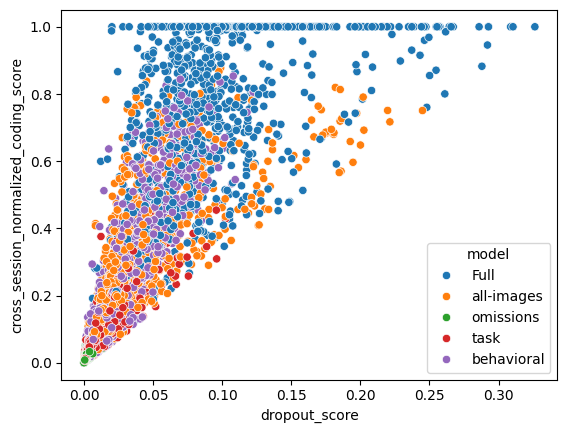

In [310]:
fig, ax = plt.subplots()
sns.scatterplot(normalized_f2n2_cs_df, x='dropout_score', y='cross_session_normalized_coding_score', hue='model', ax=ax)


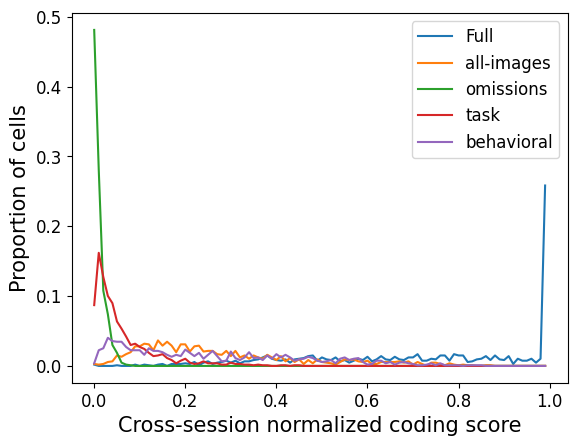

In [323]:
models = ['Full', 'all-images', 'omissions', 'task', 'behavioral']
bins = np.linspace(0, 1, 101)
fig, ax = plt.subplots()
for model in models:
    cs_values = normalized_f2n2_cs_df.query('model==@model').cross_session_normalized_coding_score.values
    hist_vals = np.histogram(cs_values, bins=bins)[0] / len(cs_values)
    ax.plot(bins[:-1], hist_vals, label=model)
ax.legend(fontsize=12)
ax.set_xlabel('Cross-session normalized coding score', fontsize=15)
ax.set_ylabel('Proportion of cells', fontsize=15)
ax.tick_params(axis='both', labelsize=12)

## Too small omissions
- check with dff responses (matt created: https://codeocean.allenneuraldynamics.org/capsule/3859967/tree?cw=true)

In [333]:
import h5py
from lamf_analysis.ophys.session_stim_response import SessionStimResponse
session_key = '736963_2024-08-05'
fn = f'/root/capsule/data/multiplane-ophys_726963_stim-response/{session_key}_session_stim_response.h5'
session_stim_response = SessionStimResponse.load(fn, format = "pandas")
df = session_stim_response.get_concatenated_planes("omissions", 
                                                    "events", 
                                                    format = "pandas")

In [342]:
df['cell_roi_id'] = df.apply(lambda x: f'{session_key}_{x.plane}_{x.cell_specimen_id:04}', axis=1)
df['response_from_baseline'] = df.mean_response - df.baseline_response

In [341]:
df.head()

,stimulus_presentations_id,cell_specimen_id,trace,trace_timestamps,mean_response,baseline_response,p_value_gray_screen,ophys_frame_rate,plane,data_type,event_type,interpolate,output_sampling_rate,response_window_duration,cell_roi_id
0,20,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.9308540413747495, -0.8377686372372745, -0....",0.004517,0.003611,0.0,10.742823,VISp_0,events,omissions,False,NaN,0.75,736963_2024-08-05_VISp_0_0000
1,20,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.9308540413747495, -0.8377686372372745, -0....",0.000000,0.000000,0.0,10.742823,VISp_0,events,omissions,False,NaN,0.75,736963_2024-08-05_VISp_0_0001
2,20,2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.9308540413747495, -0.8377686372372745, -0....",0.000000,0.000000,0.0,10.742823,VISp_0,events,omissions,False,NaN,0.75,736963_2024-08-05_VISp_0_0002
3,20,3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.9308540413747495, -0.8377686372372745, -0....",0.000068,0.000000,0.0,10.742823,VISp_0,events,omissions,False,NaN,0.75,736963_2024-08-05_VISp_0_0003
4,20,4,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.9308540413747495, -0.8377686372372745, -0....",0.000000,0.000000,0.0,10.742823,VISp_0,events,omissions,False,NaN,0.75,736963_2024-08-05_VISp_0_0004


In [352]:
omission_table = pd.DataFrame(df.groupby(['cell_roi_id'])['response_from_baseline'].mean())
omission_table

,response_from_baseline
cell_roi_id,
736963_2024-08-05_VISp_0_0000,-0.008030
736963_2024-08-05_VISp_0_0001,0.000626
736963_2024-08-05_VISp_0_0002,0.003904
736963_2024-08-05_VISp_0_0003,0.010525
736963_2024-08-05_VISp_0_0004,0.003943
...,...
736963_2024-08-05_VISp_7_0091,0.002431
736963_2024-08-05_VISp_7_0092,0.000873
736963_2024-08-05_VISp_7_0093,0.001673


In [356]:
omission_table[omission_table.response_from_baseline == omission_table.response_from_baseline.max()]

,response_from_baseline
cell_roi_id,
736963_2024-08-05_VISp_6_0015,0.046862


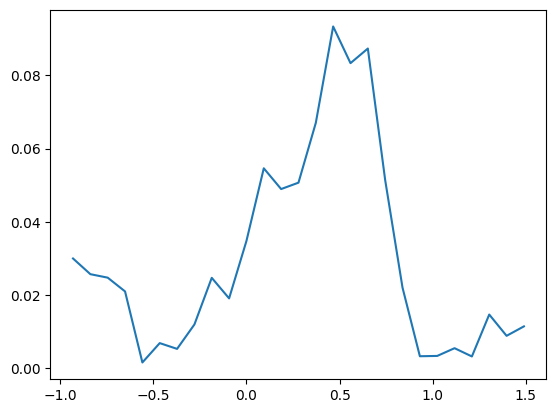

In [359]:
fig, ax = plt.subplots()
temp_rows = df[df.cell_roi_id == '736963_2024-08-05_VISp_6_0015']
ax.plot(temp_rows.trace_timestamps.values[0], temp_rows.trace.mean())

In [362]:
normalized_f2n2_cs_df['cell_roi_id'] = normalized_f2n2_cs_df.apply(lambda x: roicat_df.query(f'unique_cell_name=="{x.unique_cell_name}" and session_ind=={x.session_ind}').index.values[0], axis=1)

In [364]:
normalized_f2n2_cs_df.query('cell_roi_id=="736963_2024-08-05_VISp_6_0015"')

,session_key,unique_cell_name,model,dropout_score,session_ind,session_type,max_ve,cross_session_normalized_coding_score,cell_roi_id
1070,736963_2024-08-05,VISp_6_0024,Full,0.102921,5,OPHYS_1_images_A,0.103858,0.990978,736963_2024-08-05_VISp_6_0015
1071,736963_2024-08-05,VISp_6_0024,all-images,0.024819,5,OPHYS_1_images_A,0.103858,0.238973,736963_2024-08-05_VISp_6_0015
1072,736963_2024-08-05,VISp_6_0024,omissions,0.003009,5,OPHYS_1_images_A,0.103858,0.028975,736963_2024-08-05_VISp_6_0015
1073,736963_2024-08-05,VISp_6_0024,task,0.002173,5,OPHYS_1_images_A,0.103858,0.020921,736963_2024-08-05_VISp_6_0015
1074,736963_2024-08-05,VISp_6_0024,behavioral,0.036055,5,OPHYS_1_images_A,0.103858,0.347160,736963_2024-08-05_VISp_6_0015


In [365]:
omission_table

,response_from_baseline
cell_roi_id,
736963_2024-08-05_VISp_0_0000,-0.008030
736963_2024-08-05_VISp_0_0001,0.000626
736963_2024-08-05_VISp_0_0002,0.003904
736963_2024-08-05_VISp_0_0003,0.010525
736963_2024-08-05_VISp_0_0004,0.003943
...,...
736963_2024-08-05_VISp_7_0091,0.002431
736963_2024-08-05_VISp_7_0092,0.000873
736963_2024-08-05_VISp_7_0093,0.001673


In [367]:
omissions_cs

,session_key,unique_cell_name,model,dropout_score,session_ind,session_type,max_ve,cross_session_normalized_coding_score,cell_roi_id
2,736963_2024-08-05,VISp_0_0003,omissions,0.002525,5,OPHYS_1_images_A,0.116016,0.021764,736963_2024-08-05_VISp_0_0011
7,736963_2024-08-05,VISp_0_0007,omissions,0.002199,5,OPHYS_1_images_A,0.131815,0.016686,736963_2024-08-05_VISp_0_0017
12,736963_2024-08-05,VISp_0_0009,omissions,0.000118,5,OPHYS_1_images_A,0.163720,0.000719,736963_2024-08-05_VISp_0_0018
17,736963_2024-08-05,VISp_0_0010,omissions,0.000000,5,OPHYS_1_images_A,0.147386,0.000000,736963_2024-08-05_VISp_0_0027
22,736963_2024-08-05,VISp_0_0024,omissions,0.003251,5,OPHYS_1_images_A,0.246492,0.013187,736963_2024-08-05_VISp_0_0035
...,...,...,...,...,...,...,...,...,...
1312,736963_2024-08-05,VISp_7_0116,omissions,0.005534,5,OPHYS_1_images_A,0.104751,0.052829,736963_2024-08-05_VISp_7_0022
1317,736963_2024-08-05,VISp_7_0117,omissions,0.000205,5,OPHYS_1_images_A,0.078587,0.002614,736963_2024-08-05_VISp_7_0018
1322,736963_2024-08-05,VISp_7_0121,omissions,0.002069,5,OPHYS_1_images_A,0.121742,0.016996,736963_2024-08-05_VISp_7_0011
1327,736963_2024-08-05,VISp_7_0125,omissions,0.002156,5,OPHYS_1_images_A,0.096415,0.022361,736963_2024-08-05_VISp_7_0005


<Axes: xlabel='response_from_baseline', ylabel='cross_session_normalized_coding_score'>

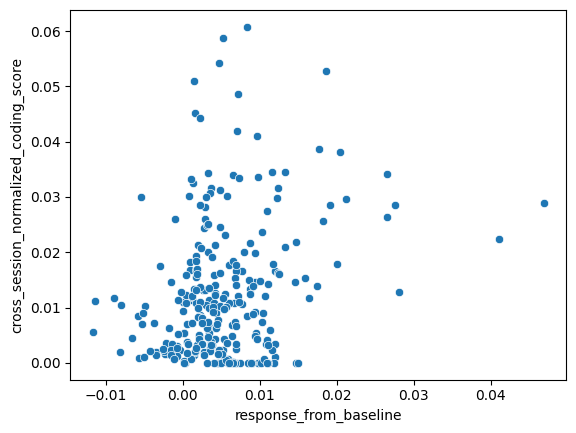

In [368]:
omissions_cs = normalized_f2n2_cs_df.query('model=="omissions" and session_key==@session_key')
omissions_cs = omissions_cs.set_index('cell_roi_id').join(omission_table, how='inner')


fig, ax = plt.subplots()
sns.scatterplot(omissions_cs, x='response_from_baseline', y='cross_session_normalized_coding_score', ax=ax)